# Linear Regression with TensorFlow (Keras)
This notebook demonstrates a simple linear regression example using TensorFlow and Keras. We will:
- Generate synthetic data
- Build and train a simple linear model
- Visualize the results and training loss.

## Importing Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

2026-02-12 12:26:53.260026: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-12 12:26:53.392967: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-12 12:26:55.076631: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Generating Synthetic Data
We generate data based on the equation $y = 4 + 3x + \text{noise}$. This helps us simulate real-world data with some randomness.

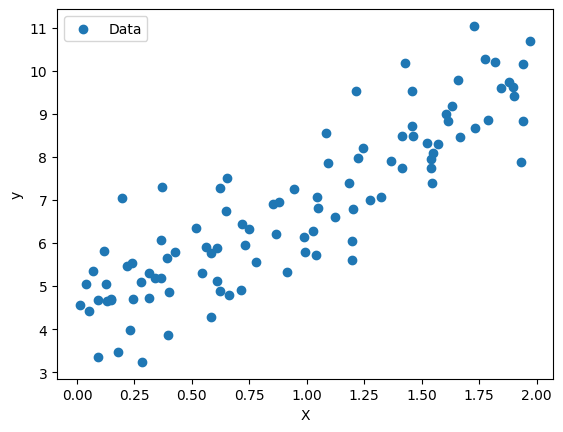

In [2]:
np.random.seed(42)
X = 2 * np.random.rand(100, 1)  # Input feature
y = 4 + 3 * X + np.random.randn(100, 1)  # True line: y = 4 + 3x + noise

plt.scatter(X, y, label="Data")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

## Building the Linear Model
We use Keras to create a simple linear regression model with a single dense layer.

In [3]:
model = Sequential([
    Dense(1, input_dim=1, activation='linear')  # Single perceptron with linear activation
])

/home/suggus/miniconda3/envs/deep_learning/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1770874016.804907   17993 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3536 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [4]:
# Show the detail of model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

## Checking Initial Weights and Bias
Before training, we inspect the initial weights and bias of the model.

In [5]:
initial_weights, initial_bias = model.layers[0].get_weights()
print("Initial weight:", initial_weights[0][0])
print("Initial bias:", initial_bias[0])

Initial weight: -1.0956917
Initial bias: 0.0


## Compiling the Model
We compile the model with the Stochastic Gradient Descent (SGD) optimizer and Mean Squared Error (MSE) loss.

In [6]:
model.compile(optimizer=SGD(learning_rate=0.01), loss='mean_squared_error')

## Training the Model
We train the model for 500 epochs and record the training loss.

In [7]:
history = model.fit(X, y, epochs=200, verbose=1)

Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 66.6273 

2026-02-12 12:26:58.750168: I external/local_xla/xla/service/service.cc:163] XLA service 0x7e3104003dc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-12 12:26:58.750196: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2026-02-12 12:26:58.768430: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900
I0000 00:00:1770874018.885267   18064 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 62.0854
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 45.0829 
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 32.0284 
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 23.3805 
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 16.8488 
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 12.4599 
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.0885  
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.9243 
Epoch 9/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.2292 
Epoch 10/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.7915 
Epoch 11/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.9478 
Epoch 12/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.2896 
Epoch 13/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.8672 
Epoch 14/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.6086 
Epoch 15/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.4060 
Epoch 16/200
4/4 ━━━━━━━

## Trained Weights and Bias
After training, we display the updated weights and bias.

In [8]:
weights, bias = model.layers[0].get_weights()
print("Trained weight:", weights[0][0])
print("Trained bias:", bias[0])

Trained weight: 2.8257449
Trained bias: 4.1838913


## Making Predictions
Using the trained model, we predict outputs for the input data.

In [9]:
y_pred = model.predict(X)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


## Visualizing the Results
We plot the original data points and the model's predictions.

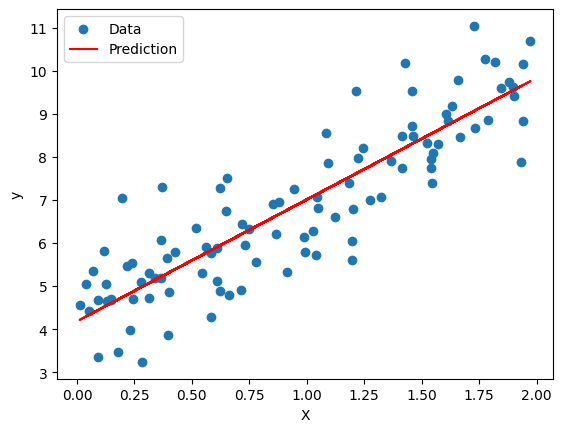

In [10]:
plt.scatter(X, y, label="Data")
plt.plot(X, y_pred, color="red", label="Prediction")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

## Plotting the Training Loss
We visualize how the loss decreases over epochs.

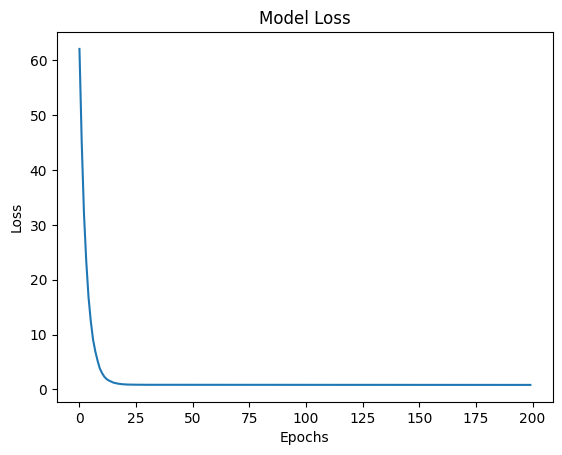

In [11]:
plt.plot(history.history['loss'])
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

-------
-------

# Try with the Polynomial line

## Generating Synthetic Data
We generate data based on the equation $y = x^2 + \text{noise}$. This helps us simulate real-world data with some randomness.

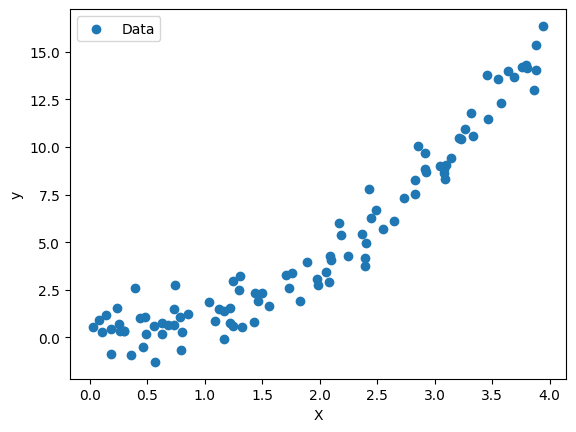

In [12]:
np.random.seed(42)
X = 4 * np.random.rand(100, 1)  # Input feature
y = X**2 + np.random.randn(100, 1)  # True line: y = x^2 + noise

plt.scatter(X, y, label="Data")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

## Build Model and Training again

In [13]:
model = Sequential([
    Dense(1, input_dim=1, activation='linear')  # Single perceptron with linear activation
])

# Show the detail of model
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
initial_weights, initial_bias = model.layers[0].get_weights()
print("Initial weight:", initial_weights[0][0])
print("Initial bias:", initial_bias[0])

Initial weight: 0.40959156
Initial bias: 0.0


In [15]:
model.compile(optimizer=SGD(learning_rate=0.01), loss='mean_squared_error')
history = model.fit(X, y, epochs=200, verbose=1)

Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 29.4162
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 15.0646 
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 8.7853  
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.6087 
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 5.8427 
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.1151 
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.7701 
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4.6634 
Epoch 9/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.5629 
Epoch 10/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4.5217
Epoch 11/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.5064 
Epoch 12/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.3559 
Epoch 13/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.2904 
Epoch 14/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4.2152 
Epoch 15/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 4.1565 
Epoch 16/200
4/4

In [16]:
weights, bias = model.layers[0].get_weights()
print("Trained weight:", weights[0][0])
print("Trained bias:", bias[0])

Trained weight: 3.8140826
Trained bias: -2.0679603


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


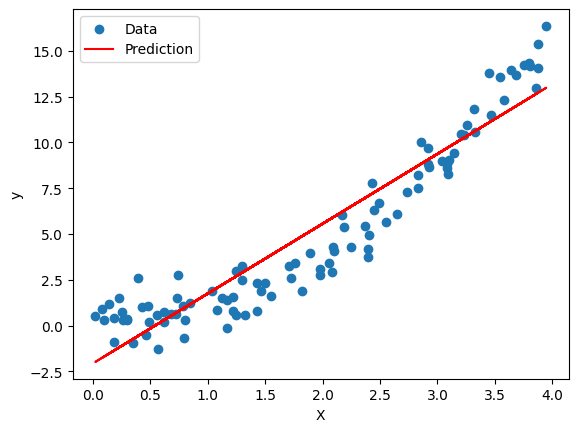

In [17]:
y_pred = model.predict(X)
plt.scatter(X, y, label="Data")
plt.plot(X, y_pred, color="red", label="Prediction")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()